In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Database.DB_reader import Database

In [2]:
db = Database()

In [3]:
query = f"""
    SELECT rel_product, value_type, value, market, del_type, delivery_start
    FROM "MODEL_forecast_prices"."xgboost_mean"
    WHERE fcst_date = '2025-03-13'
    AND rel_product in ('Q_2', 'Q_3')
    AND del_type in ('base', 'peak')
    AND market in ('de', 'fr')
    AND value_type in ('mean', 'base')
    AND scenario_type in ('base_col', 'base_sim')
"""


In [19]:
markets = ['de', 'fr']
delivery = ['base', 'peak']
periods = ['D_1', 'D_2', 'D_3', 'D_4', 'Wknd_0','Wknd_1', 'W_1', 'W_2', 'W_3']

# Build condition strings for each filter list
market_condition = ", ".join(f"'{m}'" for m in markets)
delivery_condition = ", ".join(f"'{d}'" for d in delivery)
periods_condition = ", ".join(f"'{p}'" for p in periods)

query = f"""
    SELECT rel_product, value_type, value, market, del_type, delivery_start
    FROM "MODEL_forecast_prices"."xgboost_mean"
    WHERE fcst_date = '2025-07-11'
      AND rel_product IN ({periods_condition})
      AND del_type IN ({delivery_condition})
      AND market IN ({market_condition})
      AND value_type IN ('mean', 'base')
      AND scenario_type IN ('base_col', 'base_sim')
"""



In [20]:
test = pd.read_sql(query, db.connection_string)

In [21]:
test['value_nom'] = test['value']*48.7

In [22]:
test.loc[(((test['value_type']=='base'))&
          (test['market']=='de'))]

,rel_product,value_type,value,market,del_type,delivery_start,value_nom
24,D_1,base,0.908232,de,base,2025-07-12,44.230909
25,D_2,base,1.008803,de,base,2025-07-13,49.128718
26,D_3,base,1.561653,de,base,2025-07-14,76.052485
27,D_4,base,1.443172,de,base,2025-07-15,70.282452
28,W_1,base,1.354154,de,base,2025-07-14,65.947282
29,W_2,base,1.395928,de,base,2025-07-21,67.981701
30,W_3,base,1.377669,de,base,2025-07-28,67.092462
31,Wknd_0,base,0.958518,de,base,2025-07-12,46.679813
32,Wknd_1,base,1.073509,de,base,2025-07-19,52.279876
33,D_1,base,NaN,de,peak,2025-07-12,NaN


In [18]:
test.loc[(((test['value_type']=='base'))&
          (test['market']=='fr'))]

,rel_product,value_type,value,market,del_type,delivery_start,value_nom
36,D_1,base,0.612334,fr,base,2025-07-12,29.820652
37,D_2,base,0.493841,fr,base,2025-07-13,24.050081
38,D_3,base,0.723817,fr,base,2025-07-14,35.249873
39,D_4,base,0.618054,fr,base,2025-07-15,30.099237
40,W_1,base,0.775437,fr,base,2025-07-14,37.763779
41,W_2,base,0.921266,fr,base,2025-07-21,44.865649
42,W_3,base,0.767583,fr,base,2025-07-28,37.381272
43,Wknd_0,base,0.553088,fr,base,2025-07-12,26.935366
44,Wknd_1,base,0.645573,fr,base,2025-07-19,31.439392
45,D_1,base,NaN,fr,peak,2025-07-12,NaN


In [41]:
test.loc[(((test['value_type']=='mean')))]

,rel_product,value_type,value,market,del_type,delivery_start,value_nom
2,M_1,mean,81.170626,de,base,2025-04-01,81.170626
5,M_1,mean,91.038151,at,base,2025-04-01,91.038151
6,M_1,mean,92.887643,at,peak,2025-04-01,92.887643
7,M_1,mean,78.082482,de,peak,2025-04-01,78.082482


In [30]:
query_spot = f"""
    SELECT rel_product, value_type, value, market, del_type, delivery_start
    FROM "MODEL_forecast_prices"."xgboost_mean"
    WHERE fcst_date = '2025-07-11'
    AND rel_product in ('M_1', 'M_2', 'M_3')
    AND del_type in ('base', 'peak')
    AND market in ('fr', 'de')
    AND value_type in ('base', 'mean')
    AND scenario_type IN ('base_col', 'base_sim')
"""


In [31]:
spot = pd.read_sql(query_spot, db.connection_string)

In [35]:
spot['value_nom'] = spot['value'] * (35+70*0.2)

In [36]:
spot.loc[(((spot['value_type']=='base')))]

,rel_product,value_type,value,market,del_type,delivery_start,value_nom
6,M_1,base,0.763112,fr,base,2025-08-01,37.392474
7,M_2,base,1.045201,fr,base,2025-09-01,51.214840
8,M_3,base,1.026824,fr,base,2025-10-01,50.314376
9,M_1,base,0.617469,fr,peak,2025-08-01,30.255973
10,M_2,base,1.213307,fr,peak,2025-09-01,59.452027
11,M_3,base,1.238615,fr,peak,2025-10-01,60.692119
15,M_1,base,1.414167,de,base,2025-08-01,69.294174
16,M_2,base,1.703038,de,base,2025-09-01,83.448873
17,M_3,base,1.752036,de,base,2025-10-01,85.849763
18,M_1,base,1.013578,de,peak,2025-08-01,49.665301


In [37]:
spot.loc[(((spot['value_type']=='mean')))]

,rel_product,value_type,value,market,del_type,delivery_start,value_nom
0,M_1,mean,1.547862,de,peak,2025-08-01,75.845258
1,M_2,mean,1.787988,de,peak,2025-09-01,87.611433
2,M_3,mean,1.936844,de,peak,2025-10-01,94.905361
3,M_1,mean,0.925622,fr,peak,2025-08-01,45.355495
4,M_2,mean,1.194101,fr,peak,2025-09-01,58.510965
5,M_3,mean,1.215743,fr,peak,2025-10-01,59.571398
12,M_1,mean,0.870802,fr,base,2025-08-01,42.669306
13,M_2,mean,1.027765,fr,base,2025-09-01,50.360498
14,M_3,mean,0.997203,fr,base,2025-10-01,48.862926
21,M_1,mean,1.591922,de,base,2025-08-01,78.004157


In [27]:
spot.loc[((spot['value_type'].isin([f"{str(a)}th_perc" for a in [10,25,50,75,90]]))&
          spot['rel_product'].isin(['W_1', 'Wknd_1']))]

,rel_product,value_type,value,market,del_type,delivery_start,value_nom
0,W_1,10th_perc,0.876450,de,base,2025-04-07,48.029486
1,W_1,25th_perc,1.153586,de,base,2025-04-07,63.216534
2,W_1,75th_perc,1.584746,de,base,2025-04-07,86.844055
3,W_1,90th_perc,1.745355,de,base,2025-04-07,95.645481
12,Wknd_1,10th_perc,0.130381,de,base,2025-04-12,7.144852
13,Wknd_1,25th_perc,0.641386,de,base,2025-04-12,35.147932
14,Wknd_1,75th_perc,1.296430,de,base,2025-04-12,71.044377
15,Wknd_1,90th_perc,1.500852,de,base,2025-04-12,82.246663
16,W_1,10th_perc,0.688633,de,peak,2025-04-07,37.737080
17,W_1,25th_perc,0.902638,de,peak,2025-04-07,49.464563


In [49]:
spot

,rel_product,value_type,value,market,del_type,delivery_start,value_nom
0,W_1,base,1.468613,de,base,2025-04-07,80.479987
1,W_2,base,1.309559,de,base,2025-04-14,71.763859
2,W_3,base,1.100604,de,base,2025-04-21,60.313102
3,W_1,base,1.409115,de,peak,2025-04-07,77.219487
4,W_2,base,1.163232,de,peak,2025-04-14,63.745125
5,W_3,base,0.660656,de,peak,2025-04-21,36.203925
6,W_1,mean,1.592206,de,base,2025-04-07,87.252869
7,W_2,mean,1.382713,de,base,2025-04-14,75.772670
8,W_3,mean,1.351925,de,base,2025-04-21,74.085484
9,W_1,mean,1.608364,de,peak,2025-04-07,88.138359


In [20]:
import pickle

In [110]:
file_path = r"C:\Users\krajcovic\Documents\Trading\fund_analysis\model\base_data\scen_dic_20250424.pkl"

In [111]:
with open(file_path, 'rb') as f:
    data = pickle.load(f)

In [112]:
data.keys()

dict_keys(['ExtDataSim_1', 'ExtDataSim_2', 'ExtDataSim_3', 'ExtDataSim_4', 'ExtDataSim_5', 'ExtDataSim_6', 'ExtDataSim_7', 'ExtDataSim_8', 'ExtDataSim_9', 'ExtDataSim_10', 'ExtDataSim_11', 'ExtDataSim_12', 'ExtDataSim_13', 'ExtDataSim_14', 'ExtDataSim_15', 'ExtDataSim_16', 'ExtDataSim_17', 'ExtDataSim_18', 'ExtDataSim_19', 'ExtDataSim_20', 'ExtDataSim_21', 'ExtDataSim_22', 'ExtDataSim_23', 'ExtDataSim_24', 'ExtDataSim_25', 'ExtDataSim_26', 'ExtDataSim_27', 'ExtDataSim_28', 'ExtDataSim_29', 'ExtDataSim_30', 'ExtDataSim_31', 'ExtDataSim_32', 'ExtDataSim_33', 'ExtDataSim_34', 'ExtDataSim_35', 'ExtDataSim_36', 'ExtDataSim_37', 'ExtDataSim_38', 'ExtDataSim_39', 'ExtDataSim_40', 'ExtDataSim_41', 'ExtDataSim_42', 'ExtDataSim_43', 'ExtDataSim_44', 'ExtDataSim_45', 'ExtDataSim_46', 'ExtDataSim_47', 'ExtDataSim_48', 'ExtDataSim_49', 'ExtDataSim_50', 'ExtDataSim_51', 'ExtDataSim_52', 'ExtDataSim_53', 'ExtDataSim_54', 'ExtDataSim_55', 'ExtDataSim_56', 'ExtDataSim_57', 'ExtDataSim_58', 'ExtDataSim_

In [113]:
import numpy as np
import pandas as pd
import datetime as dt
sim_dfs = [a for a in data.keys() if 'ExtDataSim_' in a]
ext_dict = []
for key in sim_dfs:
    ext_dict.append(data[key])

In [114]:
len(data['mean'].dropna())

23541

In [115]:
mean_scen = pd.DataFrame(np.sum(np.array(ext_dict),axis=0)/np.array(ext_dict).shape[0],columns=data[key].columns, index=data[key].index).copy()

In [116]:
len(mean_scen)

32352

<Axes: >

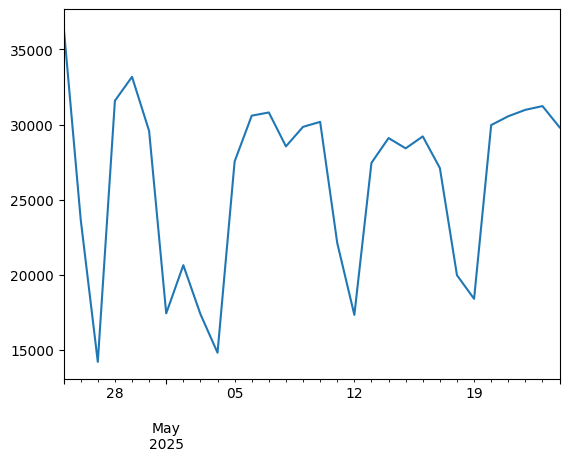

In [117]:
data['mean']['ResidualDemand_de'].iloc[:720].resample('D').mean().plot()

<Axes: >

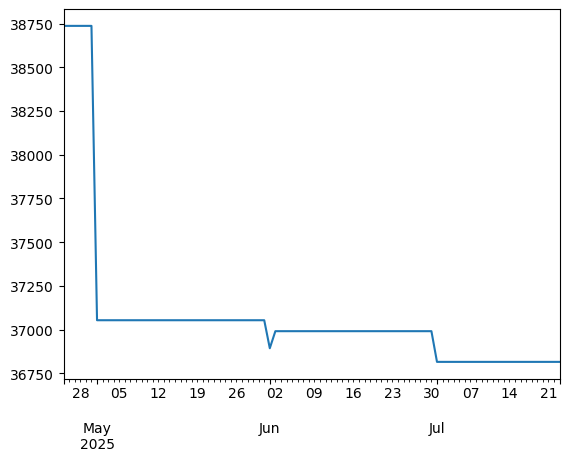

In [131]:
data['mean']['Nuc_fr'].iloc[:720*3].resample('D').mean().plot()
# mean_scen['ResidualDemand_de'].iloc[:720*3].resample('D').mean().plot()

In [119]:
base_data = data['mean']['ResidualDemand_de'].copy()
mean_data = mean_scen['ResidualDemand_de'].copy()

In [122]:
base_data.loc[dt.datetime(2025,5,4):dt.datetime(2025,5,31,23)].resample('D').mean()

2025-05-04    14823.322833
2025-05-05    27547.742250
2025-05-06    30592.415417
2025-05-07    30805.943542
2025-05-08    28551.837708
2025-05-09    29849.833292
2025-05-10    30180.186125
2025-05-11    22119.599708
2025-05-12    17338.884458
2025-05-13    27452.601083
2025-05-14    29103.072167
2025-05-15    28418.674708
2025-05-16    29214.173792
2025-05-17    27107.440708
2025-05-18    19978.317458
2025-05-19    18407.546250
2025-05-20    29968.449833
2025-05-21    30555.065250
2025-05-22    30981.137250
2025-05-23    31230.696917
2025-05-24    29816.555042
2025-05-25    22884.809500
2025-05-26    18238.743792
2025-05-27    29590.544417
2025-05-28    30943.245208
2025-05-29    30322.945583
2025-05-30    19984.303125
2025-05-31    26287.737292
Freq: D, Name: ResidualDemand_de, dtype: float64

In [44]:
mean_data.loc[dt.datetime(2025,5,12):dt.datetime(2025,5,31,23)].resample('D').mean()

2025-05-12    29610.331457
2025-05-13    31234.404036
2025-05-14    29528.013950
2025-05-15    30294.347349
2025-05-16    28904.408985
2025-05-17    20021.937392
2025-05-18    17496.759221
2025-05-19    30813.486257
2025-05-20    33201.419037
2025-05-21    32598.717632
2025-05-22    32697.825087
2025-05-23    30983.915830
2025-05-24    21861.152823
2025-05-25    16838.240982
2025-05-26    30877.858514
2025-05-27    31940.507325
2025-05-28    31719.817292
2025-05-29    19620.806974
2025-05-30    27840.424387
2025-05-31    23632.766746
Freq: D, Name: ResidualDemand_de, dtype: float64